In [ ]:
!pip install ultralytics
!yolo --version

In [ ]:
import random
import os
import shutil
import json
from ultralytics import YOLO
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Dataset :

In [ ]:
!apt-get update --fix-missing -qq

# Then install awscli
!apt-get install awscli -y -qq

In [ ]:
# Upgrade pip first (optional but recommended)
!pip install --upgrade pip --quiet

# Install AWS CLI
!pip install awscli --upgrade --quiet

# Verify installation
!aws --version

### Train Data :

In [ ]:
# Create a working directory for train set :
!mkdir -p /content/rareplanes/train

# Download data :
!aws s3 cp \
s3://rareplanes-public/real/tarballs/train/RarePlanes_train_PS-RGB_tiled.tar.gz \
/content/rareplanes/train/ \
--no-sign-request

download: s3://rareplanes-public/real/tarballs/train/RarePlanes_train_PS-RGB_tiled.tar.gz to rareplanes/train/RarePlanes_train_PS-RGB_tiled.tar.gz


In [ ]:
# Extract :
!tar -xzvf /content/rareplanes/train/RarePlanes_train_PS-RGB_tiled.tar.gz \
-C /content/rareplanes/train/

In [ ]:
# Download the data :
!aws s3 cp \
s3://rareplanes-public/real/tarballs/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz \
/content/rareplanes/train/ \
--no-sign-request

download: s3://rareplanes-public/real/tarballs/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz to rareplanes/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz


In [ ]:
# Extract :
!tar -xzvf /content/rareplanes/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz \
-C /content/rareplanes/train/

### Test data :

In [ ]:
# Create a working directory for train set :
!mkdir -p /content/rareplanes/test

# Download data :
!aws s3 cp \
s3://rareplanes-public/real/tarballs/test/RarePlanes_test_PS-RGB_tiled.tar.gz \
/content/rareplanes/test/ \
--no-sign-request

download: s3://rareplanes-public/real/tarballs/test/RarePlanes_test_PS-RGB_tiled.tar.gz to rareplanes/test/RarePlanes_test_PS-RGB_tiled.tar.gz


In [ ]:
# Extract :
!tar -xzvf /content/rareplanes/test/RarePlanes_test_PS-RGB_tiled.tar.gz \
-C /content/rareplanes/test/

In [ ]:
# Download the data :
!aws s3 cp \
s3://rareplanes-public/real/tarballs/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz \
/content/rareplanes/test/ \
--no-sign-request

download: s3://rareplanes-public/real/tarballs/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz to rareplanes/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz


In [ ]:
# Extract :
!tar -xzvf /content/rareplanes/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz \
-C /content/rareplanes/test/

_______________

# Prepare the data :

In [ ]:
!mkdir dataset

# Base dataset folder
base_path = '/content/dataset'

# Define the nested structure
folders = [
    'images/train',
    'images/val',
    'labels/train',
    'labels/val'
]

# Create the folders
for folder in folders:
    path = os.path.join(base_path, folder)
    os.makedirs(path, exist_ok=True)

print("Folder structure created successfully!")


Folder structure created successfully!


### Move test images :

In [ ]:
!mkdir -p /content/dataset/images/test
!cp -r /content/rareplanes/test/PS-RGB_tiled/* /content/dataset/images/test/

### Prepare the image folder :

We have a total of 5815 image in train set that will be split :    
- **10%** for validation
- **90%** for training

In [ ]:
train_img_dir = "/content/rareplanes/train/PS-RGB_tiled"

get_images = lambda dir: [img for img in os.listdir(dir) if img.endswith(".png")]

train_images = get_images(train_img_dir)

# Shuffle the list first to make it random
random.shuffle(train_images)

# Compute the split index
split_idx = int(0.9 * len(train_images))

# Split into train and validation
train_split = train_images[:split_idx]
val_split = train_images[split_idx:]

print(f"Train: {len(train_split)} images, Val: {len(val_split)} images")


Train: 5233 images, Val: 582 images


In [ ]:
# Upload the train split
source_dir = train_img_dir
target_dir = '/content/dataset/images/train'

for img in train_split:
    shutil.copy(os.path.join(source_dir, img), target_dir)

print(f"Copied {len(train_split)} images to {target_dir}")

Copied 5233 images to /content/dataset/images/train


In [ ]:
# Upload the val split :
source_dir = train_img_dir
target_dir = '/content/dataset/images/val'

for img in val_split:
    shutil.copy(os.path.join(source_dir, img), target_dir)

print(f"Copied {len(val_split)} images to {target_dir}")

Copied 582 images to /content/dataset/images/val


### Prepare the label folder :

In [ ]:
train_labels_dir = "/content/rareplanes/train/geojson_aircraft_tiled"

train_img_split = '/content/dataset/images/train'
val_img_split = '/content/dataset/images/val'

Transform the .geojson files to .txt format that YOLO accept

In [ ]:
import os
import json

# ===== CONFIG =====
train_labels_dir = "/content/rareplanes/train/geojson_aircraft_tiled"
output_dir = "/content/dataset/labels/train"

image_width = 512
image_height = 512

PLANE_CLASS_ID = 0  # single YOLO class: plane

os.makedirs(output_dir, exist_ok=True)

# ===== LOOP OVER ALL GEOJSON FILES =====
for file in os.listdir(train_labels_dir):
    if not file.endswith(".geojson"):
        continue

    geojson_file = os.path.join(train_labels_dir, file)
    base_name = os.path.splitext(file)[0]
    output_txt_file = os.path.join(output_dir, f"{base_name}.txt")

    # Load GeoJSON
    with open(geojson_file, "r") as f:
        data = json.load(f)

    features = data.get("features", [])
    yolo_lines = []

    # ===== Compute tile bounds from all polygons =====
    all_x, all_y = [], []

    for feature in features:
        geom = feature.get("geometry", {})
        if geom.get("type") != "Polygon":
            continue

        coords = geom["coordinates"][0]
        for pt in coords:
            all_x.append(pt[0])
            all_y.append(pt[1])

    # Skip empty tiles
    if not all_x or not all_y:
        open(output_txt_file, "w").close()
        continue

    tile_min_lon, tile_max_lon = min(all_x), max(all_x)
    tile_min_lat, tile_max_lat = min(all_y), max(all_y)

    # ===== Process each feature =====
    for feature in features:
        props = feature.get("properties", {})
        geom = feature.get("geometry", {})

        if geom.get("type") != "Polygon":
            continue

        # ✅ Only keep planes
        if props.get("is_plane") != 1:
            continue

        coords = geom["coordinates"][0]

        # Convert lon/lat → pixel coordinates
        xs_pixel = [
            (pt[0] - tile_min_lon) / (tile_max_lon - tile_min_lon) * image_width
            for pt in coords
        ]
        ys_pixel = [
            (pt[1] - tile_min_lat) / (tile_max_lat - tile_min_lat) * image_height
            for pt in coords
        ]

        xmin, xmax = min(xs_pixel), max(xs_pixel)
        ymin, ymax = min(ys_pixel), max(ys_pixel)

        # Skip tiny boxes
        if (xmax - xmin) < 1 or (ymax - ymin) < 1:
            continue

        # YOLO normalized format
        x_center = ((xmin + xmax) / 2) / image_width
        y_center = ((ymin + ymax) / 2) / image_height
        w = (xmax - xmin) / image_width
        h = (ymax - ymin) / image_height

        # Clip safety
        x_center = max(0, min(1, x_center))
        y_center = max(0, min(1, y_center))
        w = max(0, min(1, w))
        h = max(0, min(1, h))

        yolo_lines.append(
            f"{PLANE_CLASS_ID} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
        )

    # ===== Write YOLO txt =====
    with open(output_txt_file, "w") as f:
        f.write("\n".join(yolo_lines))

    print(f"Converted {geojson_file} -> {output_txt_file}")


In [ ]:
# List all files in the directory
files = os.listdir(output_dir)

# Optionally filter only files (exclude subdirectories)
files = [f for f in files if os.path.isfile(os.path.join(output_dir, f))]

# Count
num_files = len(files)

print(f"There are {num_files} files in {output_dir}")

There are 5815 files in /content/dataset/labels/train


Split the labels :           
- **10%** validation
- **90%** train

In [ ]:


# ===== CONFIG =====
train_img_split = "/content/dataset/images/train"
val_img_split   = "/content/dataset/images/val"

train_labels_split = "/content/dataset/labels/train"
val_labels_split   = "/content/dataset/labels/val"

os.makedirs(val_labels_split, exist_ok=True)

moved = 0
missing = 0

# ===== MOVE VAL LABELS OUT OF TRAIN =====
for img_file in os.listdir(val_img_split):
    if not img_file.endswith(".png"):
        continue

    base_name = os.path.splitext(img_file)[0]
    label_name = base_name + ".txt"

    src_label = os.path.join(train_labels_split, label_name)
    dst_label = os.path.join(val_labels_split, label_name)

    if not os.path.exists(src_label):
        print(f"⚠️ Missing label for VAL image: {img_file}")
        missing += 1
        continue

    shutil.move(src_label, dst_label)
    moved += 1

print(f"✅ Done.")
print(f"Moved VAL labels: {moved}")
print(f"Missing VAL labels: {missing}")


✅ Done.
Moved VAL labels: 582
Missing VAL labels: 0


### Create the data.yml file :

Check how many classes we have

In [ ]:


# ===== CONFIG =====
train_labels_dir = "/content/rareplanes/test/geojson_aircraft_tiled"

# role_id -> {"role": role_name, "count": N}
role_stats = {}

files = os.listdir(train_labels_dir)

for file in files:
    if not file.endswith(".geojson"):
        continue

    geojson_file = os.path.join(train_labels_dir, file)
    with open(geojson_file, "r") as f:
        data = json.load(f)

    features = data.get("features", [data])

    for feature in features:
        props = feature.get("properties", {})
        role_id = props.get("role_id")
        role_name = props.get("role")

        if role_id is None or role_name is None:
            continue

        if role_id not in role_stats:
            role_stats[role_id] = {
                "role": role_name,
                "count": 0
            }

        role_stats[role_id]["count"] += 1

# ===== DISPLAY RESULTS =====
print(f"Found {len(role_stats)} unique classes:\n")

for role_id in sorted(role_stats):
    role_name = role_stats[role_id]["role"]
    count = role_stats[role_id]["count"]
    print(f"role_id {role_id}: {role_name} → {count} instances")


Found 7 unique classes:

role_id 1: Small Civil Transport/Utility → 2616 instances
role_id 2: Medium Civil Transport/Utility → 2874 instances
role_id 3: Large Civil Transport/Utility → 967 instances
role_id 4: Military Transport/Utility/AWAC → 230 instances
role_id 5: Military Bomber → 4 instances
role_id 6: Military Fighter/Interceptor/Attack → 111 instances
role_id 7: Military Trainer → 10 instances


In [ ]:
yml_content = """
path: /content/dataset

train: images/train
val: images/val
test: images/test

nc: 1   # single class

names:
  0: plane
"""


# Write to a .yml file
with open("/content/dataset/data.yaml", "w") as f:
    f.write(yml_content)

print("YAML file created!")


YAML file created!


# Define the model : YOLO

In [ ]:

# ===== Define dataset yaml =====
data_yaml = "/content/dataset/data.yaml"  # Your YAML file path

# Start with pretrained YOLOv8n
model = YOLO("yolov8n.pt")  # weights from Ultralytics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# results = model.train(
#     data=data_yaml,
#     epochs=10,
#     imgsz=512,
#     batch=16,
#     name="aircraft_yolov8",
#     patience=10,         # early stopping patience
#     project="runs/train", # where to save runs
#     device=device            # GPU 0, or "cpu"
# )

results = model.train(
    data=data_yaml,
    epochs=50,           # longer training
    imgsz=640,           # larger images
    batch=16,            # depends on GPU memory
    device=device,
    patience=15,         # early stopping patience
    name="aircraft_yolov8_v2",
    project="runs/train",
    augment=True         # enable data augmentation
)



engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=aircraft_yolov8_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=runs/train, rect=False, resume=F

In [ ]:
# ===== Evaluate model separately =====
metrics = model.val()
print("Validation metrics")
print(metrics)

In [ ]:
# ===== Run inference on test/val images =====
test_images = "/content/dataset/images/val"
predictions = model.predict(
    source=test_images,
    imgsz=512,
    conf=0.25,
    save=True,
    save_txt=True
)

print("Inference completed. Predicted images and labels saved in runs/predict")

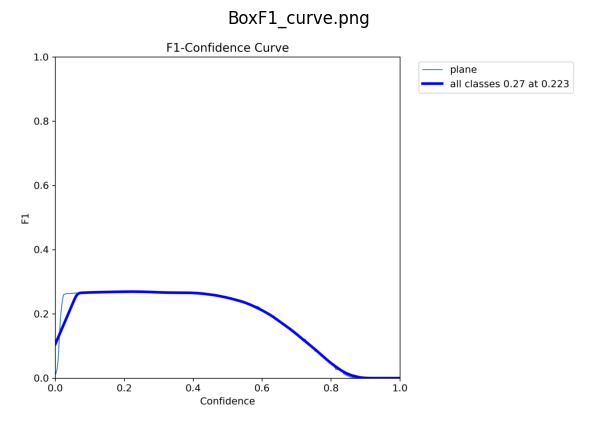

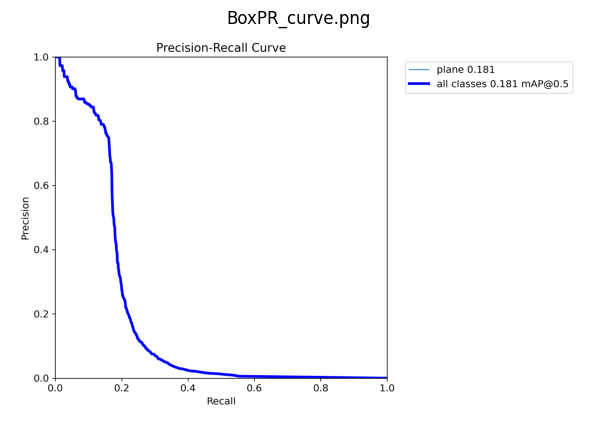

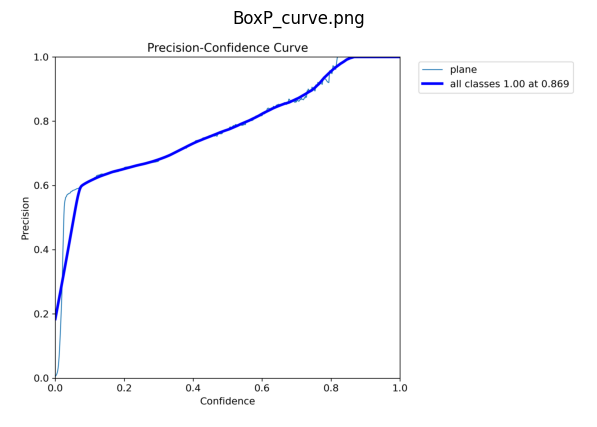

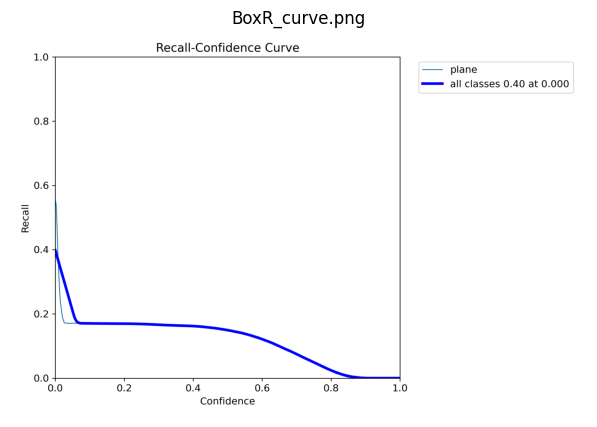

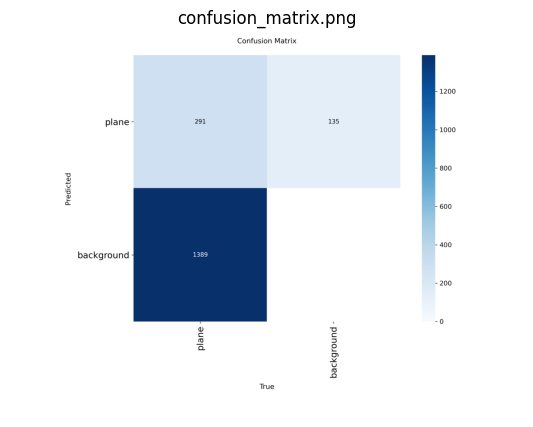

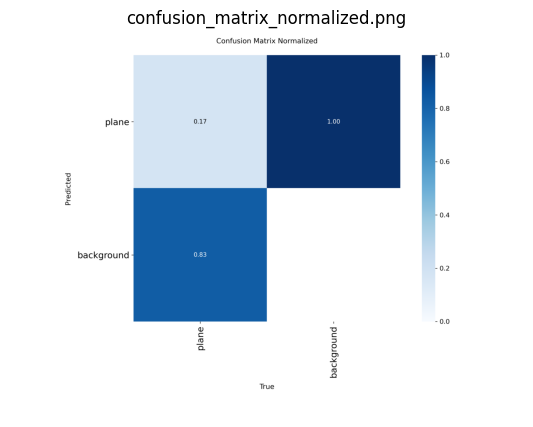

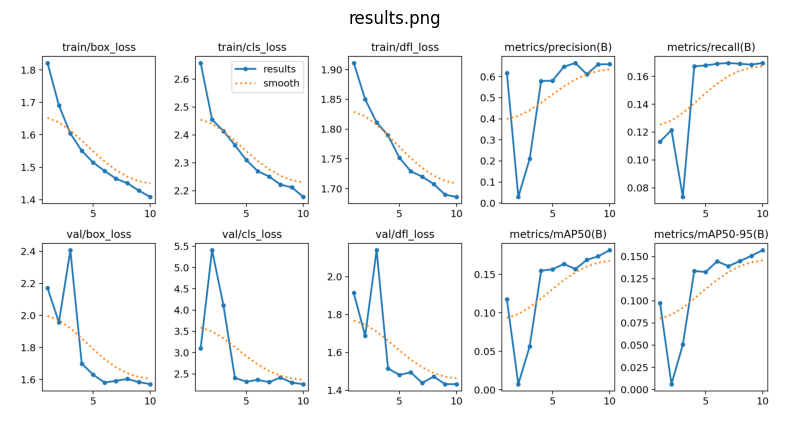

In [ ]:
run_dir = "/content/runs/train/aircraft_yolov8"

pngs = [f for f in os.listdir(run_dir) if f.lower().endswith(".png")]

if not pngs:
    print("No PNG files found.")
else:
    for png in sorted(pngs):
        img_path = os.path.join(run_dir, png)
        plt.figure(figsize=(10,5))
        plt.imshow(mpimg.imread(img_path))
        plt.axis("off")
        plt.title(png)
        plt.show()



**Problem:** A huge Class imbalance so we will just work with one class instead of 7
we will detect airplanes existant in images not they role (or type )

In [ ]:
# Evaluate on test set with explicit path
results = model.val(
    data = data_yaml,  # Direct path to test images
    imgsz=640,                    # Image size
    batch=16,                     # Batch size
    conf=0.25,                    # Confidence threshold
    iou=0.6,                      # IoU threshold
    device='0',                   # GPU device (or 'cpu')
    plots=True,                   # Generate all plots
    save_txt=True,                # Save results to txt
    save_conf=True,               # Save confidences in labels
    project='runs/test',          # Save directory
    name='test_evaluation'        # Experiment name
)

# Overall metrics
print(f"\n=== Test Set Results ===")
print(f"mAP@0.5: {results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {results.box.map:.4f}")
print(f"Precision: {results.box.mp:.4f}")
print(f"Recall: {results.box.mr:.4f}")
print(f"F1-Score: {2 * (results.box.mp * results.box.mr) / (results.box.mp + results.box.mr):.4f}")

# Per-class metrics
print("\n=== Per-Class Metrics ===")
for i, class_idx in enumerate(results.box.ap_class_index):
    class_name = model.names[class_idx]
    print(f"{class_name}:")
    print(f"  mAP@0.5: {results.box.maps[i]:.4f}")
    print(f"  Precision: {results.box.p[i]:.4f}")
    print(f"  Recall: {results.box.r[i]:.4f}")
    f1 = 2 * (results.box.p[i] * results.box.r[i]) / (results.box.p[i] + results.box.r[i]) if (results.box.p[i] + results.box.r[i]) > 0 else 0
    print(f"  F1-score: {f1:.4f}")


Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3160.9±584.2 MB/s, size: 379.4 KB)
val: Scanning /content/dataset/labels/val.cache... 582 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 582/582 788.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 3.7it/s 10.1s
                   all        582       1680      0.808      0.169      0.471      0.461
Speed: 3.0ms preprocess, 4.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/test/test_evaluation2

=== Test Set Results ===
mAP@0.5: 0.4707
mAP@0.5:0.95: 0.4605
Precision: 0.8077
Recall: 0.1690
F1-Score: 0.2796

=== Per-Class Metrics ===
plane:
  mAP@0.5: 0.4605
  Precision: 0.8077
  Recall: 0.1690
  F1-score: 0.2796
